# H&M Fashion Recommender — Data Filtering & Feature Preparation

Cleans and syncs the three core tables (articles, customers, transactions), engineers
the article metadata text used for embeddings, and produces the final filtered datasets.

Output: articles_final.parquet, customers_final.parquet, transactions_train_final.parquet





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import os
import sys
import gc
from sklearn.preprocessing import LabelEncoder


In [3]:
#import path
sys.path.append("/content/drive/MyDrive/hm_fashion_project/src")
from paths import PATHS ,BASE_DIR,BASE_PROCESS

2. Load & Clean Articles

In [26]:
df_articles=pd.read_parquet(os.path.join(PATHS['articles'],'articles.parquet'))
df_articles_copy=df_articles.copy()
df_articles_copy.drop_duplicates(subset=['article_id'],inplace=True)


In [ ]:
df_articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


3. Load & Clean Customers

In [5]:
df_customer=pd.read_parquet(os.path.join(PATHS['customers'],'customers.parquet'))
df_customer_copy=df_customer.copy()
df_customer_copy.fillna({'age': df_customer['age'].median()}, inplace=True)
df_customer_copy['Active'] = df_customer_copy['FN'].fillna(0).astype(int)
df_customer_copy['FN'] = df_customer_copy.apply(
    lambda row: int(row['FN']) if pd.notna(row['FN']) else (0 if row['Active'] == 0 else 1),
    axis=1
)
df_customer_copy['fashion_news_frequency'] = df_customer_copy['fashion_news_frequency'].replace({
    'Regular': 1,
    'NONE': 0,
    'None': 0,
    'Monthly': 2
})
df_customer_copy['fashion_news_frequency'] = df_customer_copy['fashion_news_frequency'].fillna(df_customer_copy['Active'])
df_customer_copy['club_member_status']=df_customer_copy['club_member_status'].replace({
    'ACTIVE':1,
    'LEFT CLUB':0,
    'PRE-CREATE':0.5,
})

df_customer_copy['club_member_status'] = df_customer_copy['club_member_status'].fillna(df_customer_copy['Active'])
print("Customers:", df_customer_copy.shape)



Customers: (1371980, 7)


/tmp/ipykernel_8970/4087598332.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_customer_copy['club_member_status']=df_customer_copy['club_member_status'].replace({


In [7]:
df_customer_copy.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,1.0,0,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,1.0,0,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,1.0,0,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,1.0,0,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,1.0,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [6]:
print(df_customer_copy.columns.tolist())


['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']


Load & Filter Transactions

In [8]:
df_transactions=pd.read_parquet(os.path.join(PATHS['transactions'],'transactions_train.parquet'))
df_transaction_copy=df_transactions.copy()
df_transaction_copy['t_dat']=pd.to_datetime(df_transaction_copy['t_dat'],dayfirst=True,errors='coerce')
df_transaction_copy=df_transaction_copy[df_transaction_copy['t_dat']>pd.to_datetime('2019-09-10')]
print(df_transaction_copy['t_dat'].isna().sum())

/tmp/ipykernel_8970/959524663.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_transaction_copy['t_dat']=pd.to_datetime(df_transaction_copy['t_dat'],dayfirst=True,errors='coerce')


0


In [9]:

df_transaction_copy.columns.tolist()

['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']

In [10]:
df_transaction_copy['t_dat']

,t_dat
16482301,2019-09-11
16482302,2019-09-11
16482303,2019-09-11
16482304,2019-09-11
16482305,2019-09-11
...,...
31788319,2020-09-22
31788320,2020-09-22
31788321,2020-09-22
31788322,2020-09-22


5. Standardize IDs & Sync Tables

In [27]:
df_transaction_copy['article_id'] = df_transaction_copy['article_id'].astype(str).str.zfill(10)
df_articles_copy['article_id'] = df_articles_copy['article_id'].astype(str).str.zfill(10)
df_transaction_copy['customer_id'] = df_transaction_copy['customer_id'].astype(str)
df_customer_copy['customer_id'] = df_customer_copy['customer_id'].astype(str)

df_transaction_copy = df_transaction_copy[df_transaction_copy['article_id'].isin(df_articles_copy['article_id'])]
df_transaction_copy = df_transaction_copy[df_transaction_copy['customer_id'].isin(df_customer_copy['customer_id'])]
df_customer_copy = df_customer_copy[df_customer_copy['customer_id'].isin(df_transaction_copy['customer_id'])]
df_articles_copy = df_articles_copy[df_articles_copy['article_id'].isin(df_transaction_copy['article_id'])]

In [13]:
print("Unique articles in sales:", df_transaction_copy['article_id'].nunique())
print("Unique customers in sales:", df_transaction_copy['customer_id'].nunique())

Unique articles in sales: 71846
Unique customers in sales: 1004267


In [15]:

print("--- Data Sync Report ---")
print("Unique articles in transactions:", df_transaction_copy['article_id'].nunique())
print("Articles retained:              ", df_articles_copy['article_id'].nunique())
print("Unique customers in transactions:", df_transaction_copy['customer_id'].nunique())
print("Customers retained:             ", df_customer_copy['customer_id'].nunique())

--- Data Sync Report ---
Unique articles in transactions: 71846
Articles retained:               71846
Unique customers in transactions: 1004267
Customers retained:              1004267


In [16]:
df_transaction_copy['article_id']

,article_id
16482301,0770748001
16482302,0751399004
16482303,0574109011
16482304,0751471019
16482305,0752814002
...,...
31788319,0929511001
31788320,0891322004
31788321,0918325001
31788322,0833459002


reloaded
📦 Shard 068 missing. Extracting from ZIP...
✅ Shard 068 extracted successfully.


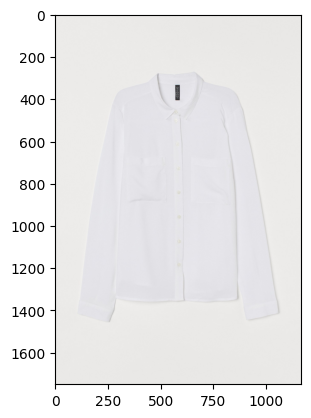

In [ ]:
from paths import get_image_path,RAW_DATA_PATH,PATHS
from utils import ensure_image_extracted
sample_id=df_transaction_copy['article_id'].sample(1).values
for a_id in sample_id:
  img_path=ensure_image_extracted(a_id)
  if img_path and os.path.exists(img_path):
    image=mpimg.imread(img_path)
    plt.imshow(image)
    plt.show()




In [17]:
df_articles_copy['article_metadata'] = (
    df_articles_copy['product_type_name'] + " " +
    df_articles_copy['department_name'] + " " +
    df_articles_copy['detail_desc'] + " " +
    df_articles_copy['colour_group_name']
).fillna('unknown').str.lower()

In [18]:
#Now Drop all the useless data
df_articles_copy=df_articles_copy.drop(columns=['graphical_appearance_no','prod_name','product_group_name','detail_desc','product_type_name','product_code','perceived_colour_value_id','perceived_colour_master_id','department_no','index_code','graphical_appearance_name','perceived_colour_value_name','colour_group_code','section_no','garment_group_no'])
df_articles_copy.head()


,article_id,product_type_no,colour_group_name,perceived_colour_master_name,department_name,index_name,index_group_no,index_group_name,section_name,garment_group_name,article_metadata
0,0108775015,253,Black,Black,Jersey Basic,Ladieswear,1,Ladieswear,Womens Everyday Basics,Jersey Basic,vest top jersey basic jersey top with narrow s...
1,0108775044,253,White,White,Jersey Basic,Ladieswear,1,Ladieswear,Womens Everyday Basics,Jersey Basic,vest top jersey basic jersey top with narrow s...
3,0110065001,306,Black,Black,Clean Lingerie,Lingeries/Tights,1,Ladieswear,Womens Lingerie,"Under-, Nightwear",bra clean lingerie microfibre t-shirt bra with...
4,0110065002,306,White,White,Clean Lingerie,Lingeries/Tights,1,Ladieswear,Womens Lingerie,"Under-, Nightwear",bra clean lingerie microfibre t-shirt bra with...
5,0110065011,306,Light Beige,Beige,Clean Lingerie,Lingeries/Tights,1,Ladieswear,Womens Lingerie,"Under-, Nightwear",bra clean lingerie microfibre t-shirt bra with...


In [19]:
gc.collect()

46

In [20]:
df_articles_copy.shape

(71846, 11)

Encode IDs to Indices

In [21]:
item_enc=LabelEncoder()
user_enc=LabelEncoder()

df_articles_copy['article_idx']=item_enc.fit_transform(df_articles_copy['article_id'])
df_customer_copy['customer_idx']=user_enc.fit_transform(df_customer_copy['customer_id'])
df_transaction_copy['article_idx']=item_enc.transform(df_transaction_copy['article_id'])
df_transaction_copy['customer_idx']=user_enc.transform(df_transaction_copy['customer_id'])

In [22]:
df_articles_copy['article_idx'] = df_articles_copy['article_idx'].astype('int32')
df_customer_copy['customer_idx'] = df_customer_copy['customer_idx'].astype('int32')

df_articles_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71846 entries, 0 to 105539
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   article_id                    71846 non-null  object
 1   product_type_no               71846 non-null  int64 
 2   colour_group_name             71846 non-null  object
 3   perceived_colour_master_name  71846 non-null  object
 4   department_name               71846 non-null  object
 5   index_name                    71846 non-null  object
 6   index_group_no                71846 non-null  int64 
 7   index_group_name              71846 non-null  object
 8   section_name                  71846 non-null  object
 9   garment_group_name            71846 non-null  object
 10  article_metadata              71846 non-null  object
 11  article_idx                   71846 non-null  int32 
dtypes: int32(1), int64(2), object(9)
memory usage: 6.9+ MB


In [23]:
#For parquet file conversion need to convert
df_customer_copy['fashion_news_frequency'] = df_customer_copy['fashion_news_frequency'].astype(str).replace('Regularly', 'Regular')
print("Data types unified for fashion_news_frequency")

Data types unified for fashion_news_frequency


In [24]:
# 1. FORCE both IDs to be 10-character strings with leading zeros
print("🔄 Standardizing IDs...")
df_articles_copy['article_id'] = df_articles_copy['article_id'].astype(str).str.zfill(10)
df_transaction_copy['article_id'] = df_transaction_copy['article_id'].astype(str).str.zfill(10)

# 2. No image filtering - all images will be available from Drive extraction
df_articles_final = df_articles_copy.copy()
print(f"👕 Total articles: {len(df_articles_final)}")

# 3. Filter Transactions
df_transaction_final = df_transaction_copy[df_transaction_copy['article_id'].isin(df_articles_final['article_id'])].copy()
print(f"🛒 Transactions matched: {len(df_transaction_final)}")

# 4. Filter Customers
active_cust_ids = set(df_transaction_final['customer_id'].unique())
df_customer_final = df_customer_copy[df_customer_copy['customer_id'].isin(active_cust_ids)].copy()
print(f"👥 Active Customers: {len(df_customer_final)}")

🔄 Standardizing IDs...
👕 Total articles: 71846
🛒 Transactions matched: 15306023
👥 Active Customers: 1004267


In [25]:
df_articles_final = df_articles_copy.copy()
df_transaction_final = df_transaction_copy[df_transaction_copy['article_id'].isin(df_articles_final['article_id'])].copy()
active_cust_ids = set(df_transaction_final['customer_id'].unique())
df_customer_final = df_customer_copy[df_customer_copy['customer_id'].isin(active_cust_ids)].copy()

print("Articles:", len(df_articles_final))
print("Transactions:", len(df_transaction_final))
print("Customers:", len(df_customer_final))

Articles: 71846
Transactions: 15306023
Customers: 1004267


In [ ]:
df_articles_final.head()

,article_id,product_type_no,colour_group_name,perceived_colour_master_name,department_name,index_name,index_group_no,index_group_name,section_name,garment_group_name,article_metadata,article_idx
0,0108775015,253,Black,Black,Jersey Basic,Ladieswear,1,Ladieswear,Womens Everyday Basics,Jersey Basic,vest top jersey basic jersey top with narrow s...,0
1,0108775044,253,White,White,Jersey Basic,Ladieswear,1,Ladieswear,Womens Everyday Basics,Jersey Basic,vest top jersey basic jersey top with narrow s...,1
3,0110065001,306,Black,Black,Clean Lingerie,Lingeries/Tights,1,Ladieswear,Womens Lingerie,"Under-, Nightwear",bra clean lingerie microfibre t-shirt bra with...,2
4,0110065002,306,White,White,Clean Lingerie,Lingeries/Tights,1,Ladieswear,Womens Lingerie,"Under-, Nightwear",bra clean lingerie microfibre t-shirt bra with...,3
5,0110065011,306,Light Beige,Beige,Clean Lingerie,Lingeries/Tights,1,Ladieswear,Womens Lingerie,"Under-, Nightwear",bra clean lingerie microfibre t-shirt bra with...,4


In [ ]:
df_articles_final.to_parquet(os.path.join(PATHS['articles'],'articles_final.parquet'),engine='pyarrow',index=False)
df_customer_final.to_parquet(os.path.join(PATHS['customers'],'customers_final.parquet'),engine='pyarrow',index=False)
df_transaction_final.to_parquet(os.path.join(PATHS['transactions'],'transactions_train_final.parquet'),engine='pyarrow',index=False)